# 6.2. fMRI Network Analysis

**Learning Objectives:**
- Understand functional connectivity in fMRI data
- Learn to extract ROI time courses from fMRI data
- Compute correlation matrices for resting-state networks
- Apply graph theory to analyze brain networks
- Identify and visualize resting-state networks
- Compare network properties across conditions or groups

**Key Concepts:**
- **Functional Connectivity**: Temporal correlations between brain regions
- **Resting-State Networks**: Spontaneously co-activating brain regions
- **Correlation Matrices**: Pairwise connectivity measures
- **Graph Theory**: Network-based analysis of brain connectivity
- **ROI-based Analysis**: Region-of-interest time course extraction
- **Network Metrics**: Degree, clustering, betweenness centrality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from scipy import stats
import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from nilearn import datasets
from nilearn import plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker, NiftiSpheresMasker
from nilearn.image import load_img, math_img
from nilearn import image

import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Understanding fMRI Connectivity

### What is Functional Connectivity in fMRI?

**Functional connectivity** in fMRI refers to temporal correlations in BOLD signal fluctuations between different brain regions, measured while the brain is at rest or during a task.

**Key Characteristics:**
- **Temporal resolution**: ~1-3 seconds (limited by hemodynamic response)
- **Spatial resolution**: Excellent (~1-3 mm)
- **Measure**: Pearson correlation between ROI time courses
- **Interpretation**: Regions with high correlation are functionally connected

### Resting-State Networks (RSNs)

**Resting-state networks** are sets of brain regions that show synchronized activity when the brain is at rest (not performing a specific task). Major networks include:

| Network | Key Regions | Function |
|---------|-------------|----------|
| **Default Mode Network (DMN)** | Posterior cingulate, medial prefrontal, lateral parietal | Self-referential thought, mind-wandering |
| **Executive Control Network** | Dorsolateral prefrontal, anterior cingulate | Cognitive control, decision-making |
| **Salience Network** | Anterior insula, anterior cingulate | Detecting relevant stimuli |
| **Sensorimotor Network** | Motor cortex, somatosensory cortex | Motor planning and execution |
| **Visual Network** | Occipital cortex, visual areas | Visual processing |
| **Auditory Network** | Superior temporal gyrus | Auditory processing |

### fMRI Connectivity vs EEG/MEG Connectivity

| Aspect | fMRI | EEG/MEG |
|--------|------|---------|
| **Temporal Resolution** | Seconds | Milliseconds |
| **Spatial Resolution** | Excellent (mm) | Poor to good |
| **Connectivity Measure** | Correlation | Coherence, PLV, etc. |
| **Volume Conduction** | Not an issue | Major concern |
| **Best For** | Spatial networks | Temporal dynamics |

## 2. Load Sample fMRI Data

We'll use the Nilearn development dataset, which contains resting-state fMRI data from children and adolescents.

In [3]:
# Download development dataset (resting-state fMRI)
data_dir = Path("./").resolve().parents[1] / "datasets" / "fmri_sample"
data_dir.mkdir(parents=True, exist_ok=True)

# Fetch the development dataset
development_dataset = datasets.fetch_development_fmri(
    n_subjects=1,  # Use 1 subject for this tutorial
    data_dir=str(data_dir),
    verbose=1
)

print(f"Dataset downloaded to: {data_dir}")
print(f"Number of subjects: {len(development_dataset.func)}")
print(f"Number of confounds: {len(development_dataset.confounds)}")

[fetch_development_fmri] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_sample/development_fmri
[fetch_development_fmri] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_sample/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_sample/development_fmri/development_fmri
Dataset downloaded to: /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_sample
Number of subjects: 1
Number of confounds: 1


In [4]:
# Load the first subject's data
func_file = development_dataset.func[0]
confounds_file = development_dataset.confounds[0]

# Load the functional image
func_img = load_img(func_file)
print(f"Functional image shape: {func_img.shape}")
print(f"Affine shape: {func_img.affine.shape}")
print(f"Voxel size: {np.diag(func_img.affine[:3, :3])}")

# Load confounds (motion parameters, etc.)
confounds = pd.read_csv(confounds_file, sep='\t')
print(f"\nConfounds shape: {confounds.shape}")
print(f"Confounds columns: {list(confounds.columns[:10])}...")

Functional image shape: (50, 59, 50, 168)
Affine shape: (4, 4)
Voxel size: [4. 4. 4.]

Confounds shape: (168, 15)
Confounds columns: ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'framewise_displacement', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02']...


## 3. Extract ROI Time Courses

### 3.1. Load an Atlas

We'll use the Harvard-Oxford atlas to define regions of interest (ROIs) for connectivity analysis.

In [5]:
# Load Harvard-Oxford cortical atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_filename = atlas.maps
labels = atlas.labels

print(f"Atlas file: {atlas_filename}")
print(f"Number of regions: {len(labels)}")
print(f"\nFirst 10 regions:")
for i, label in enumerate(labels[:10]):
    print(f"  {i}: {label}")

[fetch_atlas_harvard_oxford] Dataset created in /Users/yibeisita/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...
Downloaded 2449408 of 25716861 bytes (9.5%%,    9.5s remaining)
Downloaded 5152768 of 25716861 bytes (20.0%%,    8.0s remaining)
Downloaded 7610368 of 25716861 bytes (29.6%%,    7.2s remaining)
Downloaded 10625024 of 25716861 bytes (41.3%%,    5.7s remaining)
Downloaded 12951552 of 25716861 bytes (50.4%%,    5.0s remaining)
Downloaded 15884288 of 25716861 bytes (61.8%%,    3.7s remaining)
Downloaded 19144704 of 25716861 bytes (74.4%%,    2.4s remaining)
Downloaded 21798912 of 25716861 bytes (84.8%%,    1.5s remaining)
Downloaded 23879680 of 25716861 bytes (92.9%%,    0.7s remaining)
[fetch_atlas_harvard_oxford]  ...done. (11 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from /Users/yibeisita/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...
[fetch_atlas_

In [6]:
# Select specific ROIs for connectivity analysis
# Focus on key regions from major networks
selected_roi_indices = [
    2,   # Frontal Pole (Executive Network)
    3,   # Insular Cortex (Salience Network)
    4,   # Superior Frontal Gyrus (Executive Network)
    5,   # Middle Frontal Gyrus (Executive Network)
    8,   # Inferior Frontal Gyrus (Executive Network)
    12,  # Precentral Gyrus (Motor Network)
    13,  # Temporal Pole (Default Mode Network)
    14,  # Superior Temporal Gyrus (Auditory Network)
    15,  # Middle Temporal Gyrus (Default Mode Network)
    20,  # Inferior Temporal Gyrus (Visual Network)
    21,  # Postcentral Gyrus (Somatosensory Network)
    22,  # Superior Parietal Lobule (Attention Network)
    23,  # Supramarginal Gyrus (Default Mode Network)
    24,  # Angular Gyrus (Default Mode Network)
    25,  # Lateral Occipital Cortex (Visual Network)
    26,  # Intracalcarine Cortex (Visual Network)
    27,  # Frontal Medial Cortex (Default Mode Network)
    28,  # Juxtapositional Lobule (Motor Network)
    29,  # Subcallosal Cortex (Default Mode Network)
    30,  # Paracingulate Gyrus (Executive Network)
    31,  # Cingulate Gyrus (Default Mode Network)
    32,  # Precuneus (Default Mode Network)
    33,  # Cuneus (Visual Network)
    34,  # Frontal Orbital Cortex (Default Mode Network)
    35,  # Parahippocampal Gyrus (Memory Network)
    36,  # Lingual Gyrus (Visual Network)
    37,  # Temporal Fusiform Cortex (Visual Network)
    38,  # Temporal Occipital Fusiform Cortex (Visual Network)
    39,  # Occipital Fusiform Gyrus (Visual Network)
    40,  # Frontal Operculum Cortex (Language Network)
    41,  # Central Opercular Cortex (Language Network)
    42,  # Parietal Operculum Cortex (Somatosensory Network)
    43,  # Planum Polare (Auditory Network)
    44,  # Heschl's Gyrus (Auditory Network)
    45,  # Planum Temporale (Language Network)
    46,  # Supracalcarine Cortex (Visual Network)
    47,  # Occipital Pole (Visual Network)
]

selected_labels = [labels[i] for i in selected_roi_indices]
print(f"Selected {len(selected_roi_indices)} ROIs for analysis")
print(f"\nSample regions:")
for i, idx in enumerate(selected_roi_indices[:10]):
    print(f"  {i}: {labels[idx]}")

Selected 37 ROIs for analysis

Sample regions:
  0: Insular Cortex
  1: Superior Frontal Gyrus
  2: Middle Frontal Gyrus
  3: Inferior Frontal Gyrus, pars triangularis
  4: Temporal Pole
  5: Middle Temporal Gyrus, posterior division
  6: Middle Temporal Gyrus, temporooccipital part
  7: Inferior Temporal Gyrus, anterior division
  8: Inferior Temporal Gyrus, posterior division
  9: Supramarginal Gyrus, posterior division


In [7]:
# Create a masker to extract time courses from ROIs
masker = NiftiLabelsMasker(
    labels_img=atlas_filename,
    labels=labels,
    standardize=True,  # Z-score normalize
    memory='nilearn_cache',
    verbose=1
)

# Extract time courses for all regions
time_series = masker.fit_transform(func_img, confounds=confounds)

print(f"Time series shape: {time_series.shape}")
print(f"Number of time points: {time_series.shape[0]}")
print(f"Number of ROIs: {time_series.shape[1]}")

# Extract only selected ROIs
time_series_selected = time_series[:, selected_roi_indices]
print(f"\nSelected ROIs time series shape: {time_series_selected.shape}")

[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x130f3e890>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract(<nibabel.nifti1.Nifti1Image object at 0x130f2d9d0>, <nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x13120f350>, { 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': True,
  'labels': [ 'Background',
              'Frontal Pole',
              'Insular Cortex',
              'Superior Frontal Gyrus',
              'Middle Frontal Gyrus',
              'Inferior Frontal Gyrus, pars triangularis',
              'Inferior Frontal Gyrus, pars opercularis',
             

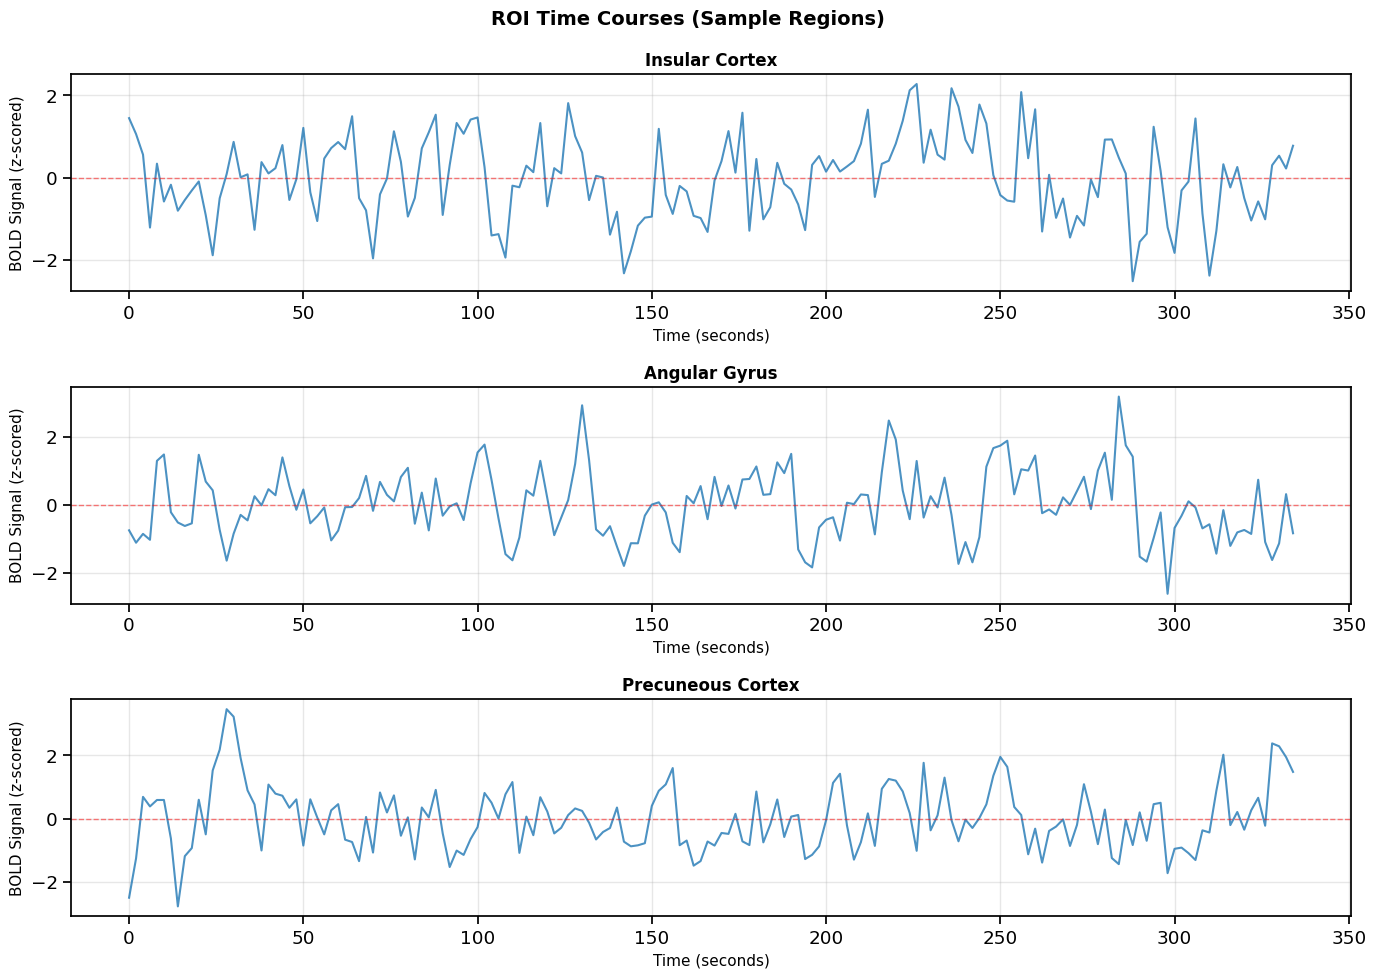


Time course statistics:
  Insular Cortex                : Mean=-0.000, Std=1.000, Range=[-2.52, 2.28]
  Angular Gyrus                 : Mean=-0.000, Std=1.000, Range=[-2.62, 3.19]
  Precuneous Cortex             : Mean=0.000, Std=1.000, Range=[-2.77, 3.45]


In [8]:
# Visualize a few ROI time courses
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Select a few representative ROIs
sample_indices = [0, 10, 20]  # Frontal Pole, Postcentral Gyrus, Precuneus
sample_names = [selected_labels[i] for i in sample_indices]

time_points = np.arange(time_series_selected.shape[0]) * 2.0  # Assuming 2s TR

for idx, (roi_idx, roi_name) in enumerate(zip(sample_indices, sample_names)):
    axes[idx].plot(time_points, time_series_selected[:, roi_idx], 
                   linewidth=1.5, alpha=0.8)
    axes[idx].set_title(f'{roi_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Time (seconds)', fontsize=11)
    axes[idx].set_ylabel('BOLD Signal (z-scored)', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('ROI Time Courses (Sample Regions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTime course statistics:")
for idx, name in zip(sample_indices, sample_names):
    ts = time_series_selected[:, idx]
    print(f"  {name[:30]:30s}: Mean={np.mean(ts):.3f}, Std={np.std(ts):.3f}, Range=[{np.min(ts):.2f}, {np.max(ts):.2f}]")

## 4. Compute Correlation Matrix

The correlation matrix represents pairwise functional connectivity between all ROI pairs.

In [9]:
# Compute correlation matrix using ConnectivityMeasure
connectivity_measure = ConnectivityMeasure(
    kind='correlation',
    vectorize=False  # Return full matrix, not vectorized
)

# Compute connectivity matrix
correlation_matrix = connectivity_measure.fit_transform([time_series_selected])[0]

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"Matrix is symmetric: {np.allclose(correlation_matrix, correlation_matrix.T)}")
print(f"Diagonal values (should be 1.0): {np.diag(correlation_matrix)[:5]}")

# Statistics
triu_indices = np.triu_indices_from(correlation_matrix, k=1)
corr_values = correlation_matrix[triu_indices]

print(f"\nCorrelation statistics (excluding diagonal):")
print(f"  Min: {np.min(corr_values):.3f}")
print(f"  Max: {np.max(corr_values):.3f}")
print(f"  Mean: {np.mean(corr_values):.3f}")
print(f"  Median: {np.median(corr_values):.3f}")
print(f"  Std: {np.std(corr_values):.3f}")

Correlation matrix shape: (37, 37)
Matrix is symmetric: True
Diagonal values (should be 1.0): [1. 1. 1. 1. 1.]

Correlation statistics (excluding diagonal):
  Min: -0.233
  Max: 0.801
  Mean: 0.163
  Median: 0.127
  Std: 0.207


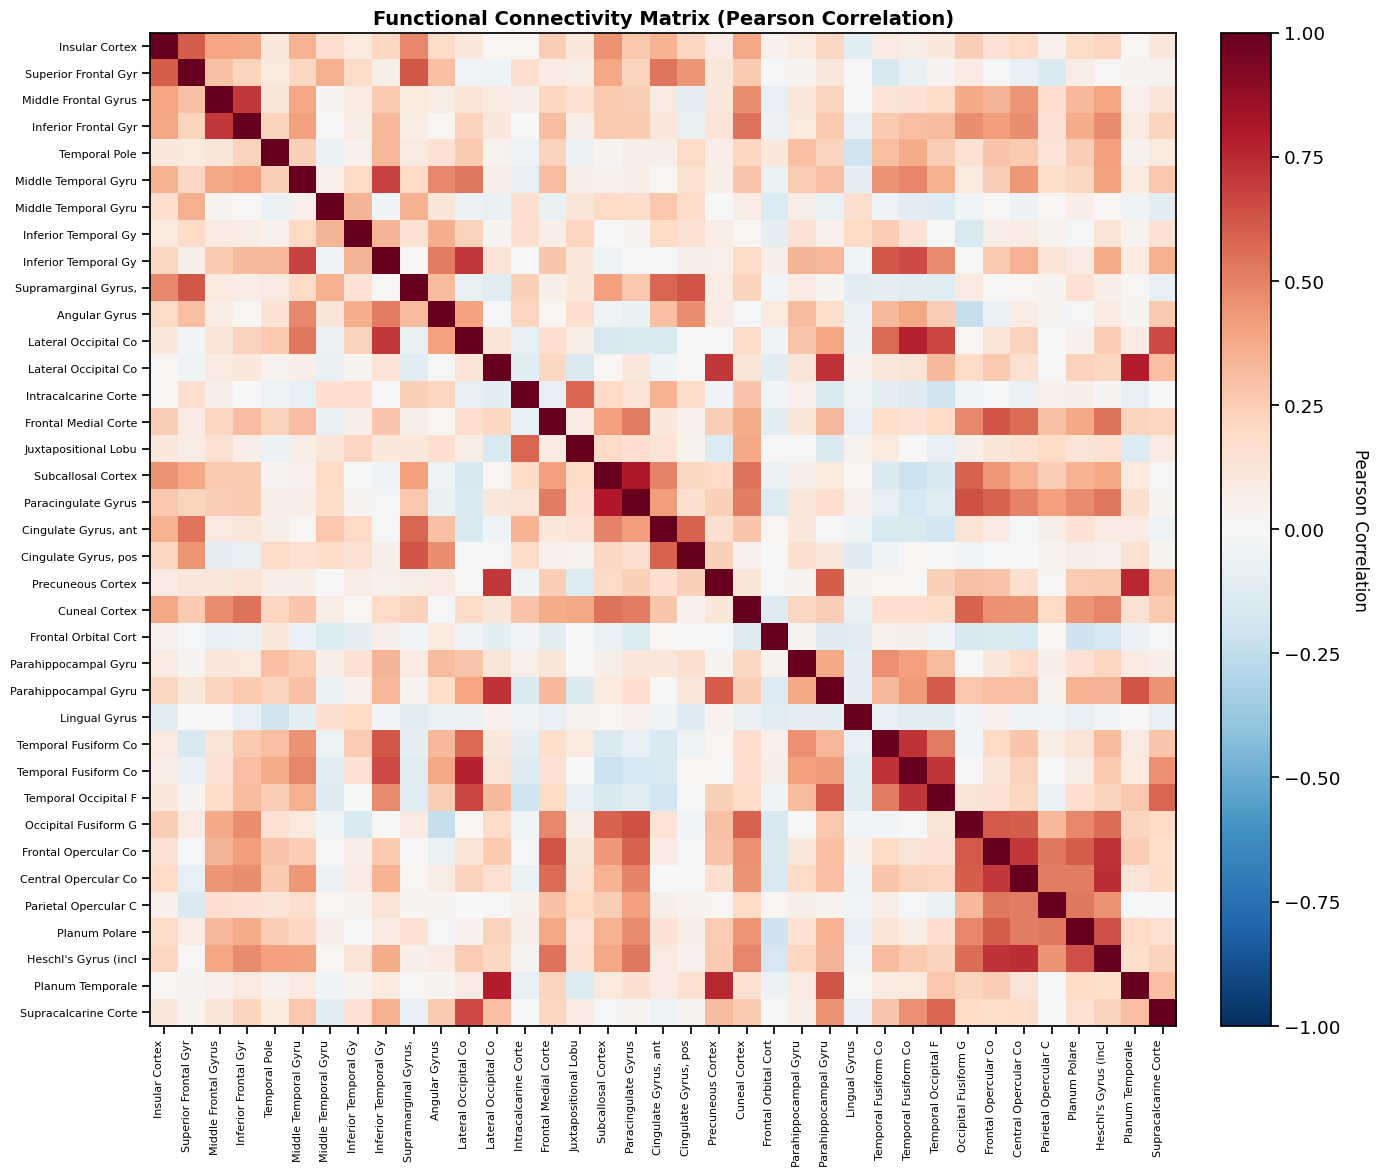

In [12]:
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(14, 12))

# Create a mask for the diagonal (to show it differently if needed)
mask = np.eye(len(selected_labels), dtype=bool)

# Plot correlation matrix
im = ax.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto', interpolation='nearest')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation', rotation=270, labelpad=20, fontsize=12)

abbreviated_labels = [label[:20] if len(label) > 20 else label for label in selected_labels]
ax.set_xticks(range(len(selected_labels)))
ax.set_yticks(range(len(selected_labels)))
ax.set_xticklabels(abbreviated_labels, rotation=90, ha='right', fontsize=8)
ax.set_yticklabels(abbreviated_labels, fontsize=8)

ax.set_title('Functional Connectivity Matrix (Pearson Correlation)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

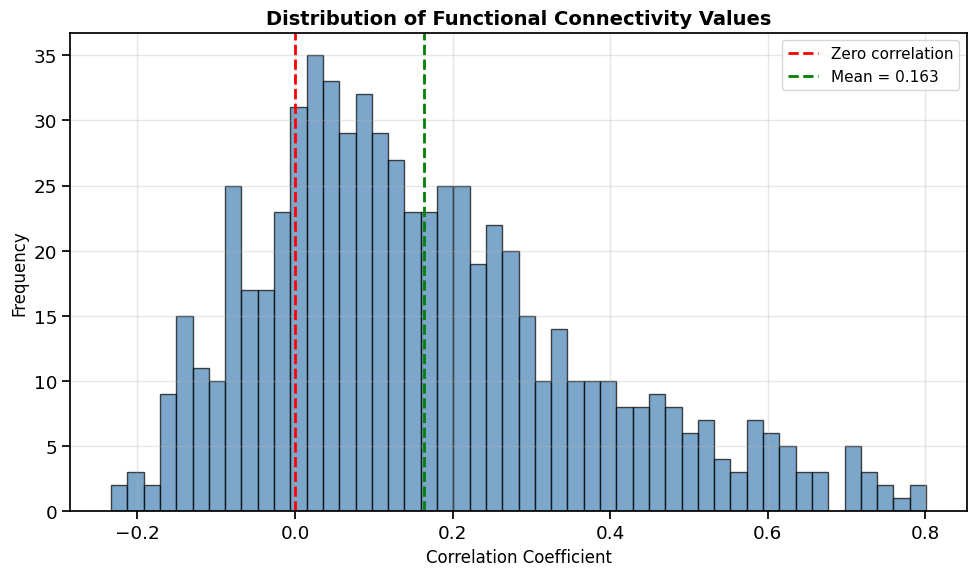


Proportion of connections:
  Positive correlations: 78.4%
  Negative correlations: 21.6%
  Strong positive (r > 0.3): 22.7%
  Strong negative (r < -0.3): 0.0%


In [13]:
# Distribution of correlation values
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(corr_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero correlation')
ax.axvline(x=np.mean(corr_values), color='green', linestyle='--', linewidth=2, 
           label=f'Mean = {np.mean(corr_values):.3f}')

ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Functional Connectivity Values', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nProportion of connections:")
print(f"  Positive correlations: {np.sum(corr_values > 0) / len(corr_values) * 100:.1f}%")
print(f"  Negative correlations: {np.sum(corr_values < 0) / len(corr_values) * 100:.1f}%")
print(f"  Strong positive (r > 0.3): {np.sum(corr_values > 0.3) / len(corr_values) * 100:.1f}%")
print(f"  Strong negative (r < -0.3): {np.sum(corr_values < -0.3) / len(corr_values) * 100:.1f}%")

## 5. Graph Theory Analysis

### 5.1. Threshold the Connectivity Matrix

To create a binary network, we threshold the correlation matrix to keep only the strongest connections.

In [14]:
# Threshold connectivity matrix
# Keep top 20% of connections (absolute value)
threshold_percentile = 80  # Keep connections above 80th percentile

# Get threshold value
threshold = np.percentile(np.abs(corr_values), threshold_percentile)
print(f"Connection threshold (absolute correlation): {threshold:.3f}")

# Create binary adjacency matrix
adjacency_matrix = (np.abs(correlation_matrix) > threshold).astype(int)
np.fill_diagonal(adjacency_matrix, 0)  # No self-connections

# Statistics
n_connections = np.sum(adjacency_matrix) // 2  # Divide by 2 because matrix is symmetric
n_possible = len(selected_labels) * (len(selected_labels) - 1) // 2
density = n_connections / n_possible

print(f"\nNetwork statistics:")
print(f"  Total connections: {n_connections}")
print(f"  Possible connections: {n_possible}")
print(f"  Network density: {density:.3f}")
print(f"  Percentage of possible connections: {density * 100:.1f}%")

Connection threshold (absolute correlation): 0.326

Network statistics:
  Total connections: 133
  Possible connections: 666
  Network density: 0.200
  Percentage of possible connections: 20.0%


In [15]:
# Create NetworkX graph from adjacency matrix
G = nx.from_numpy_array(adjacency_matrix)

# Compute network metrics
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
clustering = nx.clustering(G)
strength = {i: np.sum(np.abs(correlation_matrix[i, :])) for i in range(len(selected_labels))}

# Create summary DataFrame
network_metrics = pd.DataFrame({
    'ROI': [label[:30] for label in selected_labels],
    'Degree': [degree[i] for i in range(len(selected_labels))],
    'Strength': [strength[i] for i in range(len(selected_labels))],
    'Betweenness': [betweenness[i] for i in range(len(selected_labels))],
    'Clustering': [clustering[i] for i in range(len(selected_labels))]
})

# Sort by degree
network_metrics = network_metrics.sort_values('Degree', ascending=False)

print("Network Metrics (Top 15 by Degree):")
print(network_metrics.head(15).to_string(index=False))

Network Metrics (Top 15 by Degree):
                           ROI  Degree  Strength  Betweenness  Clustering
Heschl's Gyrus (includes H1 an      15 11.618221     0.123145    0.495238
Parahippocampal Gyrus, posteri      13 10.579566     0.191159    0.320513
      Central Opercular Cortex      13 10.881582     0.048271    0.615385
Inferior Temporal Gyrus, poste      13  9.577984     0.121907    0.397436
            Subcallosal Cortex      12  9.580760     0.085888    0.545455
                 Cuneal Cortex      12 10.754823     0.060465    0.636364
                 Planum Polare      12  9.593654     0.049442    0.681818
      Frontal Opercular Cortex      11 10.575871     0.004951    0.781818
Middle Temporal Gyrus, posteri      11  9.809240     0.100977    0.418182
      Occipital Fusiform Gyrus      10  9.598139     0.001512    0.866667
Temporal Fusiform Cortex, post      10  9.503052     0.024365    0.555556
           Paracingulate Gyrus      10 10.076333     0.028023    0.733333
In

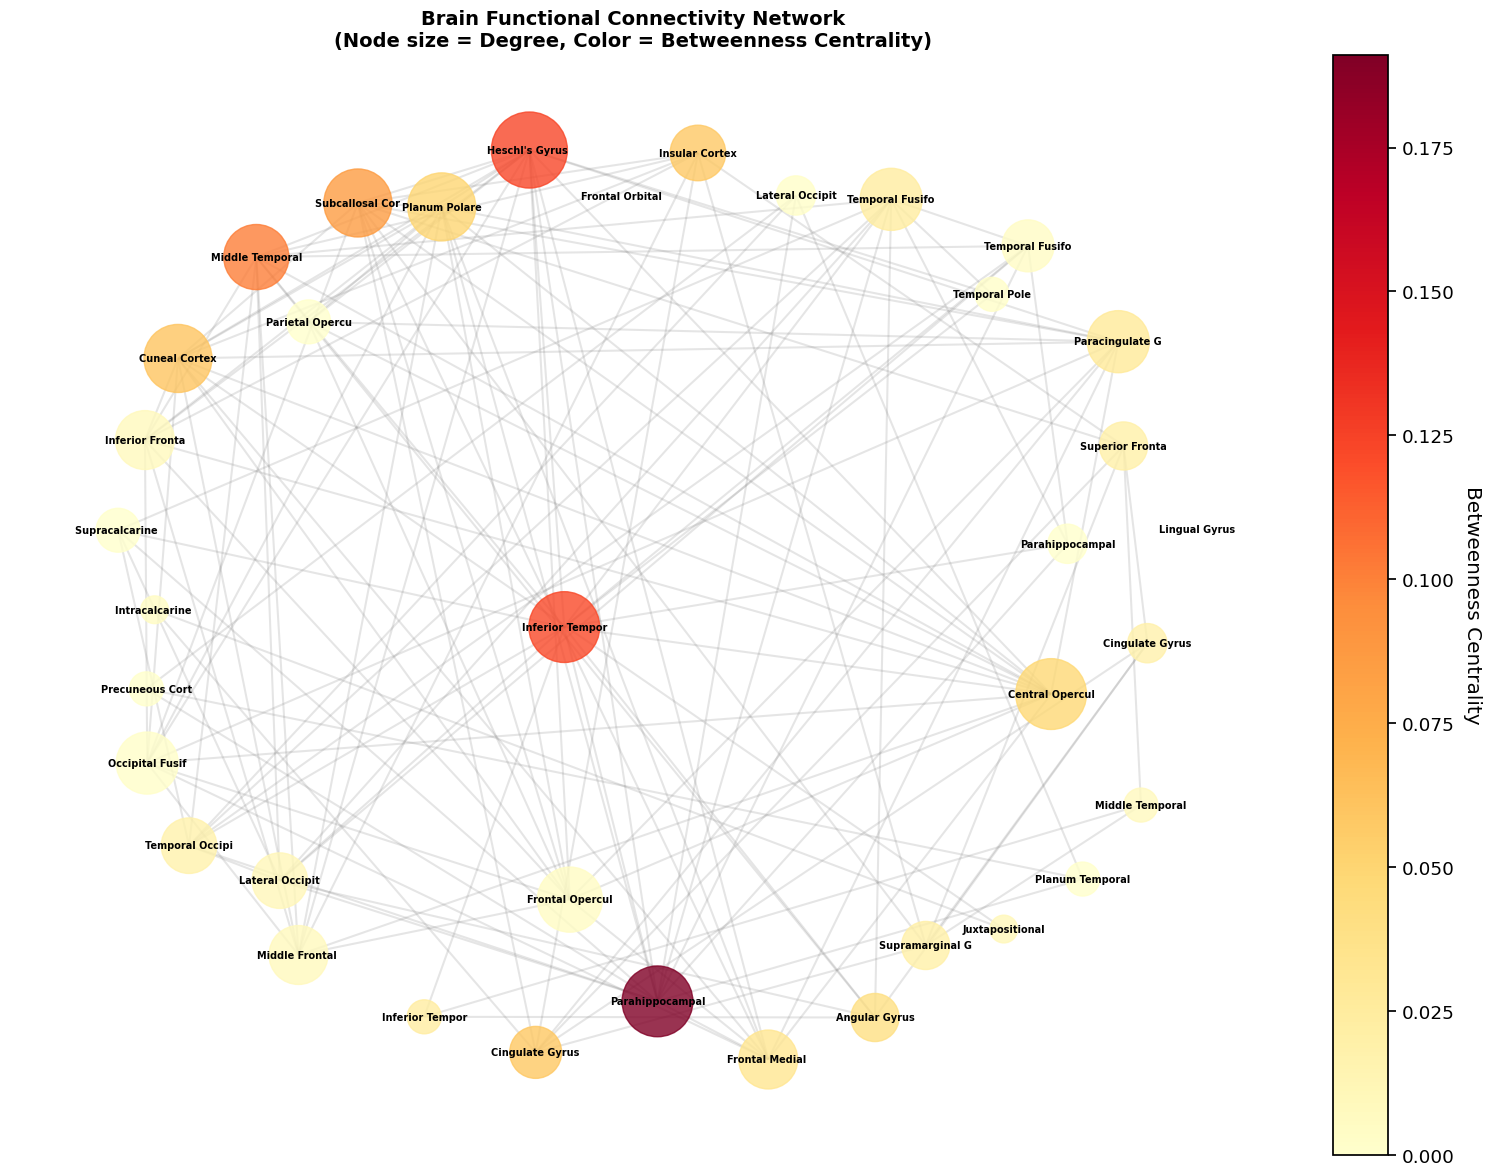


Hub Regions (Top 10 by Degree):
  Heschl's Gyrus (includes H1 an: Degree = 15, Betweenness = 0.123
  Parahippocampal Gyrus, posteri: Degree = 13, Betweenness = 0.191
  Central Opercular Cortex      : Degree = 13, Betweenness = 0.048
  Inferior Temporal Gyrus, poste: Degree = 13, Betweenness = 0.122
  Subcallosal Cortex            : Degree = 12, Betweenness = 0.086
  Cuneal Cortex                 : Degree = 12, Betweenness = 0.060
  Planum Polare                 : Degree = 12, Betweenness = 0.049
  Frontal Opercular Cortex      : Degree = 11, Betweenness = 0.005
  Middle Temporal Gyrus, posteri: Degree = 11, Betweenness = 0.101
  Occipital Fusiform Gyrus      : Degree = 10, Betweenness = 0.002


In [16]:
# Visualize network graph
fig, ax = plt.subplots(figsize=(16, 12))

# Create layout (force-directed)
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Node sizes based on degree
node_sizes = [degree[i] * 200 for i in range(len(selected_labels))]

# Node colors based on betweenness centrality
node_colors = [betweenness[i] for i in range(len(selected_labels))]

# Draw network
nodes = nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    cmap='YlOrRd', vmin=0, vmax=max(node_colors) if max(node_colors) > 0 else 1,
    ax=ax, alpha=0.8
)

# Draw edges
nx.draw_networkx_edges(
    G, pos, alpha=0.2, width=1.5, edge_color='gray', ax=ax
)

# Labels (abbreviate)
labels_dict = {i: label[:15] if len(label) > 15 else label 
               for i, label in enumerate(selected_labels)}
nx.draw_networkx_labels(
    G, pos, labels_dict, font_size=7, font_weight='bold', ax=ax
)

# Colorbar
if max(node_colors) > 0:
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', 
                               norm=plt.Normalize(vmin=0, vmax=max(node_colors)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Betweenness Centrality', rotation=270, labelpad=20)

ax.set_title('Brain Functional Connectivity Network\n(Node size = Degree, Color = Betweenness Centrality)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# Identify hub nodes (high degree)
print("\nHub Regions (Top 10 by Degree):")
top_hubs = network_metrics.head(10)
for idx, row in top_hubs.iterrows():
    print(f"  {row['ROI']:30s}: Degree = {row['Degree']:.0f}, "
          f"Betweenness = {row['Betweenness']:.3f}")

### 5.2. Global Network Metrics

Compute overall network properties that characterize the entire brain network.

In [17]:
# Compute global network metrics
global_metrics = {
    'Density': nx.density(G),
    'Average Degree': np.mean(list(degree.values())),
    'Average Clustering': nx.average_clustering(G),
    'Global Efficiency': nx.global_efficiency(G),
    'Transitivity': nx.transitivity(G),
    'Average Path Length': nx.average_shortest_path_length(G) if nx.is_connected(G) else np.nan,
    'Number of Components': nx.number_connected_components(G),
    'Largest Component Size': len(max(nx.connected_components(G), key=len)) if nx.number_connected_components(G) > 0 else 0
}

print("Global Network Metrics:")
print("=" * 50)
for metric_name, value in global_metrics.items():
    if not np.isnan(value):
        if isinstance(value, float):
            print(f"  {metric_name:25s}: {value:.4f}")
        else:
            print(f"  {metric_name:25s}: {value}")
    else:
        print(f"  {metric_name:25s}: N/A (graph not fully connected)")

# Small-world properties
# Compare to random graph with same number of nodes and edges
random_G = nx.gnm_random_graph(len(selected_labels), n_connections, seed=42)
random_clustering = nx.average_clustering(random_G)
random_path_length = nx.average_shortest_path_length(random_G) if nx.is_connected(random_G) else np.nan

if not np.isnan(global_metrics['Average Path Length']):
    small_world_index = (global_metrics['Average Clustering'] / random_clustering) / \
                       (global_metrics['Average Path Length'] / random_path_length)
    
    print(f"\nSmall-World Properties:")
    print(f"  Clustering ratio (C/C_random): {global_metrics['Average Clustering'] / random_clustering:.3f}")
    print(f"  Path length ratio (L/L_random): {global_metrics['Average Path Length'] / random_path_length:.3f}")
    print(f"  Small-world index (σ): {small_world_index:.3f}")
    
    if small_world_index > 1:
        print("  → Network exhibits small-world properties!")
    else:
        print("  → Network does not show strong small-world properties")

Global Network Metrics:
  Density                  : 0.1997
  Average Degree           : 7.1892
  Average Clustering       : 0.5849
  Global Efficiency        : 0.4822
  Transitivity             : 0.6022
  Average Path Length      : N/A (graph not fully connected)
  Number of Components     : 3
  Largest Component Size   : 35


## 6. Resting-State Networks

### 6.1. Identify Network Communities

We can identify resting-state networks by clustering highly connected regions.

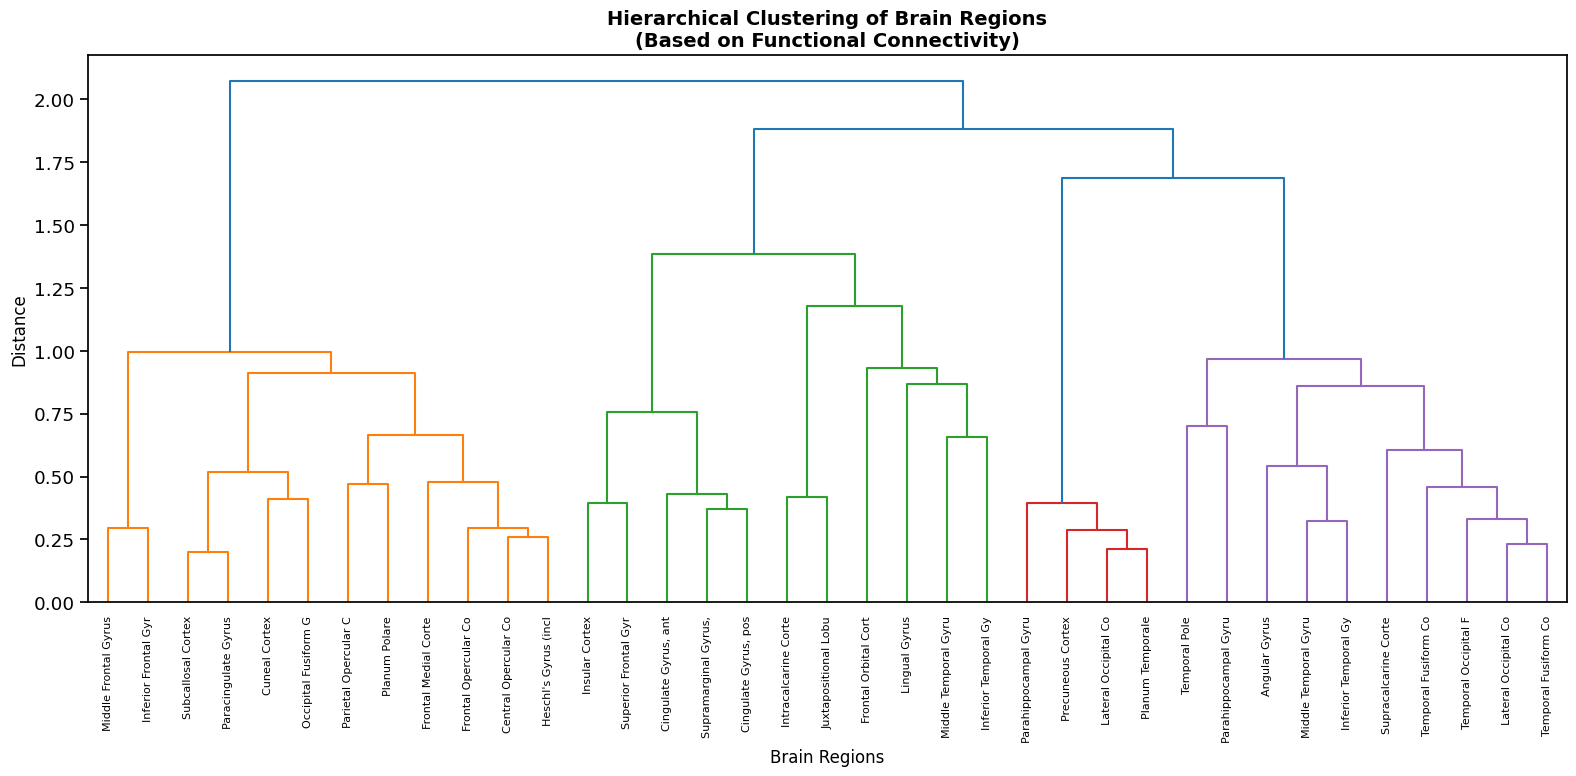

In [18]:
# Use hierarchical clustering to identify network communities
# Convert correlation to distance (1 - correlation)
distance_matrix = 1 - np.abs(correlation_matrix)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(distance_matrix, checks=False), method='ward')

# Visualize dendrogram
fig, ax = plt.subplots(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    labels=[label[:20] for label in selected_labels],
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax
)

ax.set_title('Hierarchical Clustering of Brain Regions\n(Based on Functional Connectivity)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Brain Regions', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)

plt.tight_layout()
plt.show()

In [19]:
# Extract communities using modularity-based community detection
from networkx.algorithms import community

# Find communities using greedy modularity maximization
communities = list(community.greedy_modularity_communities(G))

print(f"Found {len(communities)} network communities")
print("\nNetwork Communities:")
print("=" * 60)

for i, comm in enumerate(communities):
    comm_list = list(comm)
    print(f"\nCommunity {i+1} ({len(comm_list)} regions):")
    for node_idx in sorted(comm_list):
        print(f"  - {selected_labels[node_idx]}")

# Create community assignment for visualization
community_labels = np.zeros(len(selected_labels), dtype=int)
for i, comm in enumerate(communities):
    for node_idx in comm:
        community_labels[node_idx] = i

print(f"\nCommunity sizes: {[len(c) for c in communities]}")

Found 5 network communities

Network Communities:

Community 1 (14 regions):
  - Temporal Pole
  - Middle Temporal Gyrus, posterior division
  - Inferior Temporal Gyrus, posterior division
  - Angular Gyrus
  - Lateral Occipital Cortex, superior division
  - Lateral Occipital Cortex, inferior division
  - Precuneous Cortex
  - Parahippocampal Gyrus, anterior division
  - Parahippocampal Gyrus, posterior division
  - Temporal Fusiform Cortex, anterior division
  - Temporal Fusiform Cortex, posterior division
  - Temporal Occipital Fusiform Cortex
  - Planum Temporale
  - Supracalcarine Cortex

Community 2 (13 regions):
  - Middle Frontal Gyrus
  - Inferior Frontal Gyrus, pars triangularis
  - Intracalcarine Cortex
  - Frontal Medial Cortex
  - Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
  - Paracingulate Gyrus
  - Cuneal Cortex
  - Occipital Fusiform Gyrus
  - Frontal Opercular Cortex
  - Central Opercular Cortex
  - Parietal Opercular Cortex
  - Planum Polare
  

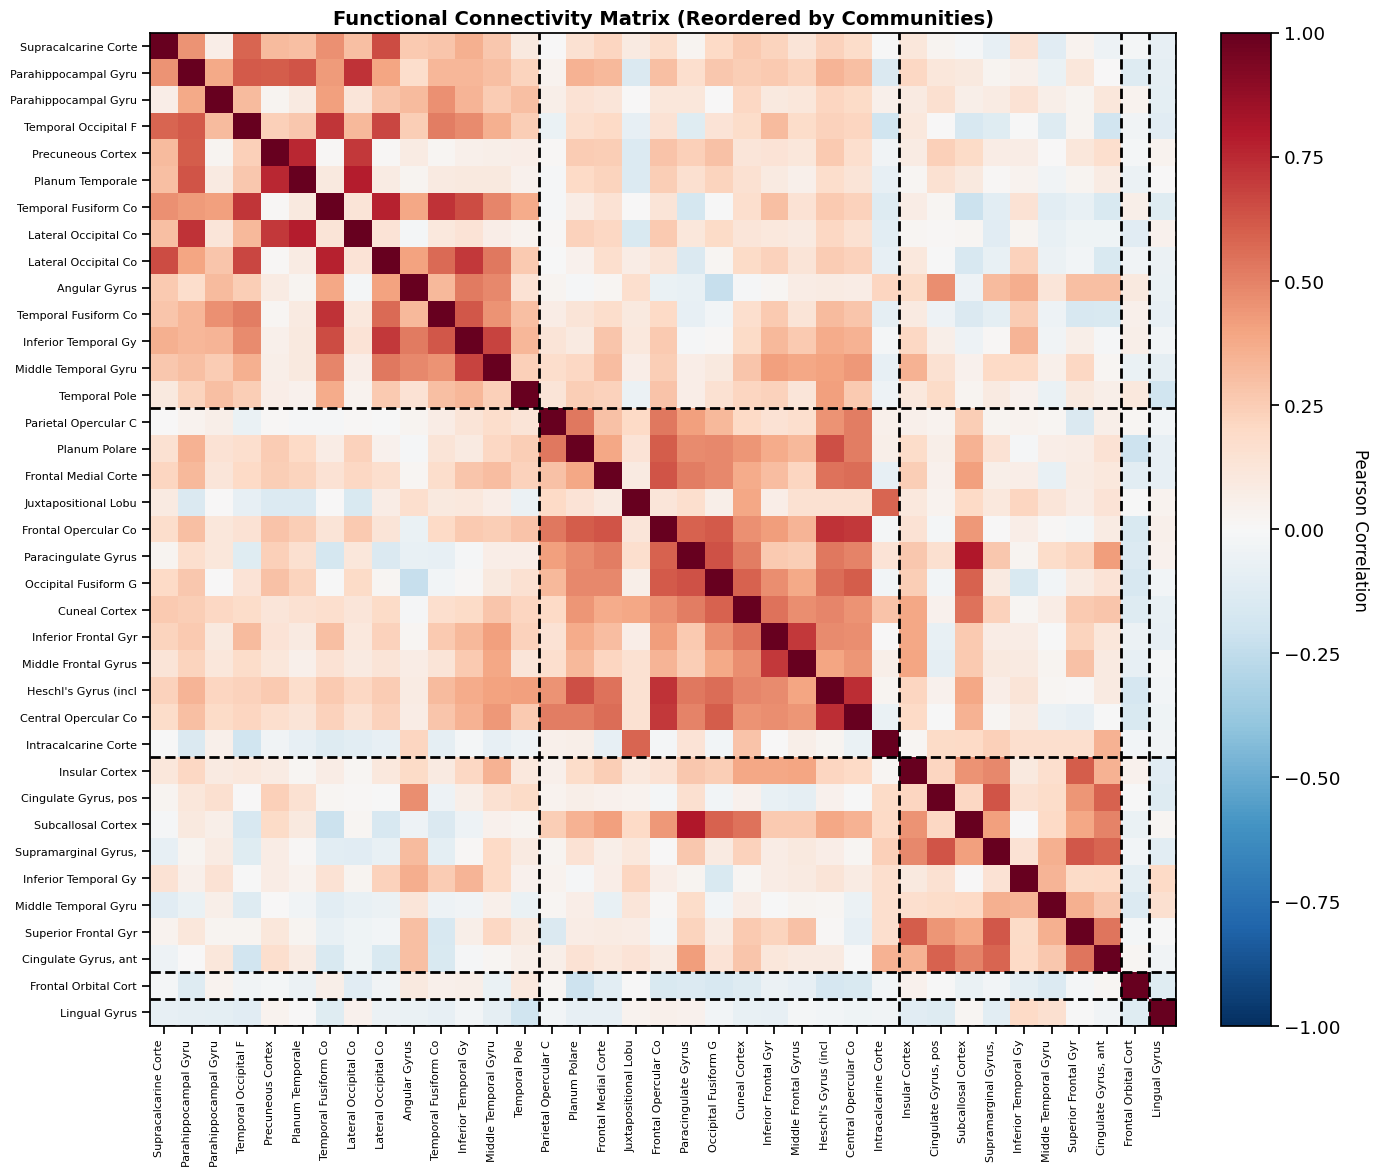

In [21]:
# Visualize correlation matrix with community structure
fig, ax = plt.subplots(figsize=(14, 12))

# Reorder matrix by communities
community_order = np.argsort(community_labels)
reordered_matrix = correlation_matrix[np.ix_(community_order, community_order)]
reordered_labels = [selected_labels[i] for i in community_order]

# Plot
im = ax.imshow(reordered_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto', interpolation='nearest')

# Add community boundaries
cumulative = 0
for comm_size in [len(c) for c in communities]:
    cumulative += comm_size
    ax.axhline(y=cumulative - 0.5, color='black', linewidth=2, linestyle='--')
    ax.axvline(x=cumulative - 0.5, color='black', linewidth=2, linestyle='--')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation', rotation=270, labelpad=20, fontsize=12)

abbreviated_labels = [label[:20] if len(label) > 20 else label for label in reordered_labels]
ax.set_xticks(range(len(reordered_labels)))
ax.set_yticks(range(len(reordered_labels)))
ax.set_xticklabels(abbreviated_labels, rotation=90, ha='right', fontsize=8)
ax.set_yticklabels(abbreviated_labels, fontsize=8)

ax.set_title('Functional Connectivity Matrix (Reordered by Communities)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2. Compute Within- vs Between-Network Connectivity

Compare connectivity strength within networks vs between networks.

In [22]:
# Compute within-network and between-network connectivity
within_network_connections = []
between_network_connections = []

for i in range(len(selected_labels)):
    for j in range(i + 1, len(selected_labels)):
        corr_value = correlation_matrix[i, j]
        if community_labels[i] == community_labels[j]:
            # Same community (within-network)
            within_network_connections.append(corr_value)
        else:
            # Different communities (between-network)
            between_network_connections.append(corr_value)

within_network_connections = np.array(within_network_connections)
between_network_connections = np.array(between_network_connections)

print("Connectivity Statistics:")
print("=" * 50)
print(f"Within-Network Connections:")
print(f"  Count: {len(within_network_connections)}")
print(f"  Mean: {np.mean(within_network_connections):.3f}")
print(f"  Std: {np.std(within_network_connections):.3f}")
print(f"\nBetween-Network Connections:")
print(f"  Count: {len(between_network_connections)}")
print(f"  Mean: {np.mean(between_network_connections):.3f}")
print(f"  Std: {np.std(between_network_connections):.3f}")

# Statistical test
t_stat, p_value = stats.ttest_ind(within_network_connections, 
                                   between_network_connections)
print(f"\nT-test (within vs between):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.2e}")
if p_value < 0.05:
    print("  → Significant difference (within > between)")
else:
    print("  → No significant difference")

Connectivity Statistics:
Within-Network Connections:
  Count: 197
  Mean: 0.346
  Std: 0.212

Between-Network Connections:
  Count: 469
  Mean: 0.086
  Std: 0.148

T-test (within vs between):
  t-statistic: 18.045
  p-value: 1.56e-59
  → Significant difference (within > between)


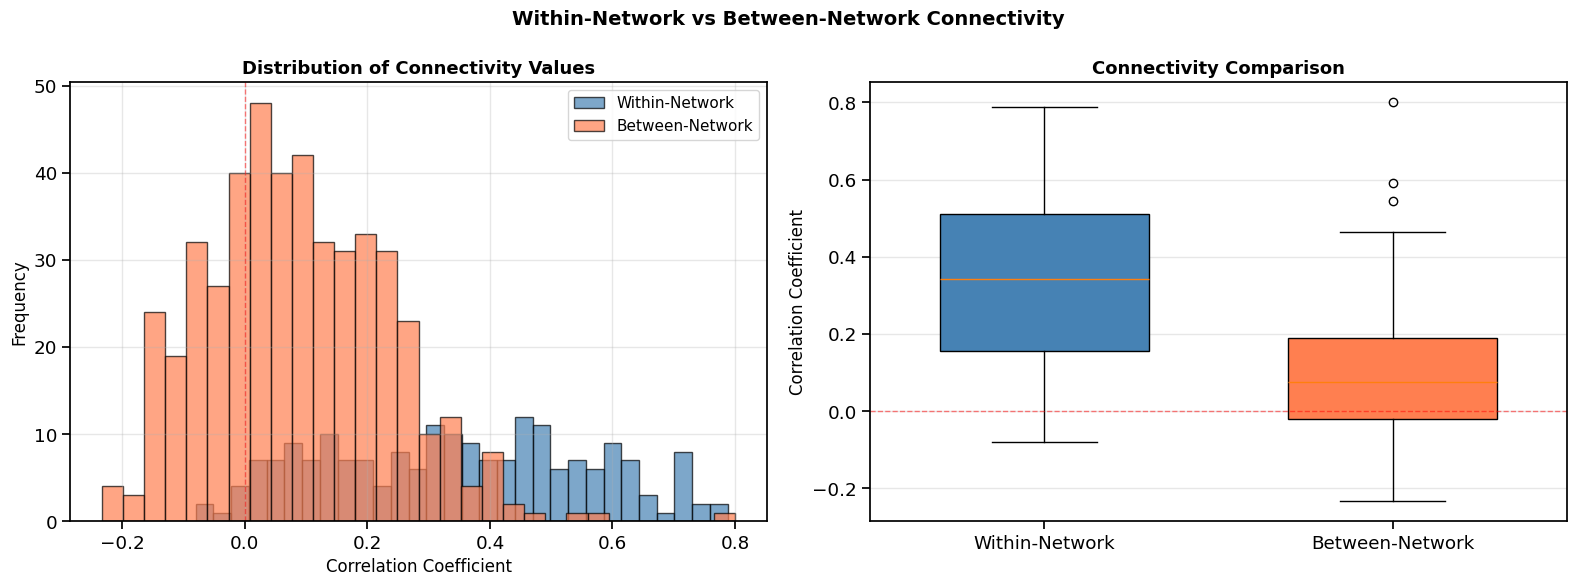

In [24]:
# Visualize within vs between network connectivity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram comparison
axes[0].hist(within_network_connections, bins=30, alpha=0.7, label='Within-Network', color='steelblue', edgecolor='black')
axes[0].hist(between_network_connections, bins=30, alpha=0.7, label='Between-Network', color='coral', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Correlation Coefficient', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Connectivity Values', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot comparison
box_data = [within_network_connections, between_network_connections]
bp = axes[1].boxplot(box_data, labels=['Within-Network', 'Between-Network'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('Correlation Coefficient', fontsize=12)
axes[1].set_title('Connectivity Comparison', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Within-Network vs Between-Network Connectivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Network Visualization on Brain

Visualize the network directly on brain anatomy using Nilearn's plotting functions.

In [25]:
# Get coordinates for each ROI (centroids)
# We'll use the atlas to get ROI coordinates
from nilearn.image import resample_to_img
from nilearn.plotting import find_parcellation_cut_coords

# Get coordinates for the selected ROIs
coords = find_parcellation_cut_coords(labels_img=atlas_filename)

# Select coordinates for our ROIs
selected_coords = coords[selected_roi_indices]

print(f"ROI coordinates shape: {selected_coords.shape}")
print(f"Sample coordinates (first 3 ROIs):")
for i in range(3):
    print(f"  {selected_labels[i]}: {selected_coords[i]}")

ROI coordinates shape: (37, 3)
Sample coordinates (first 3 ROIs):
  Insular Cortex: [-14.19385343  18.7927502   56.64223798]
  Superior Frontal Gyrus: [-38.32087114  18.58511797  42.33901996]
  Middle Frontal Gyrus: [-49.99341021  28.57001647   8.80395387]


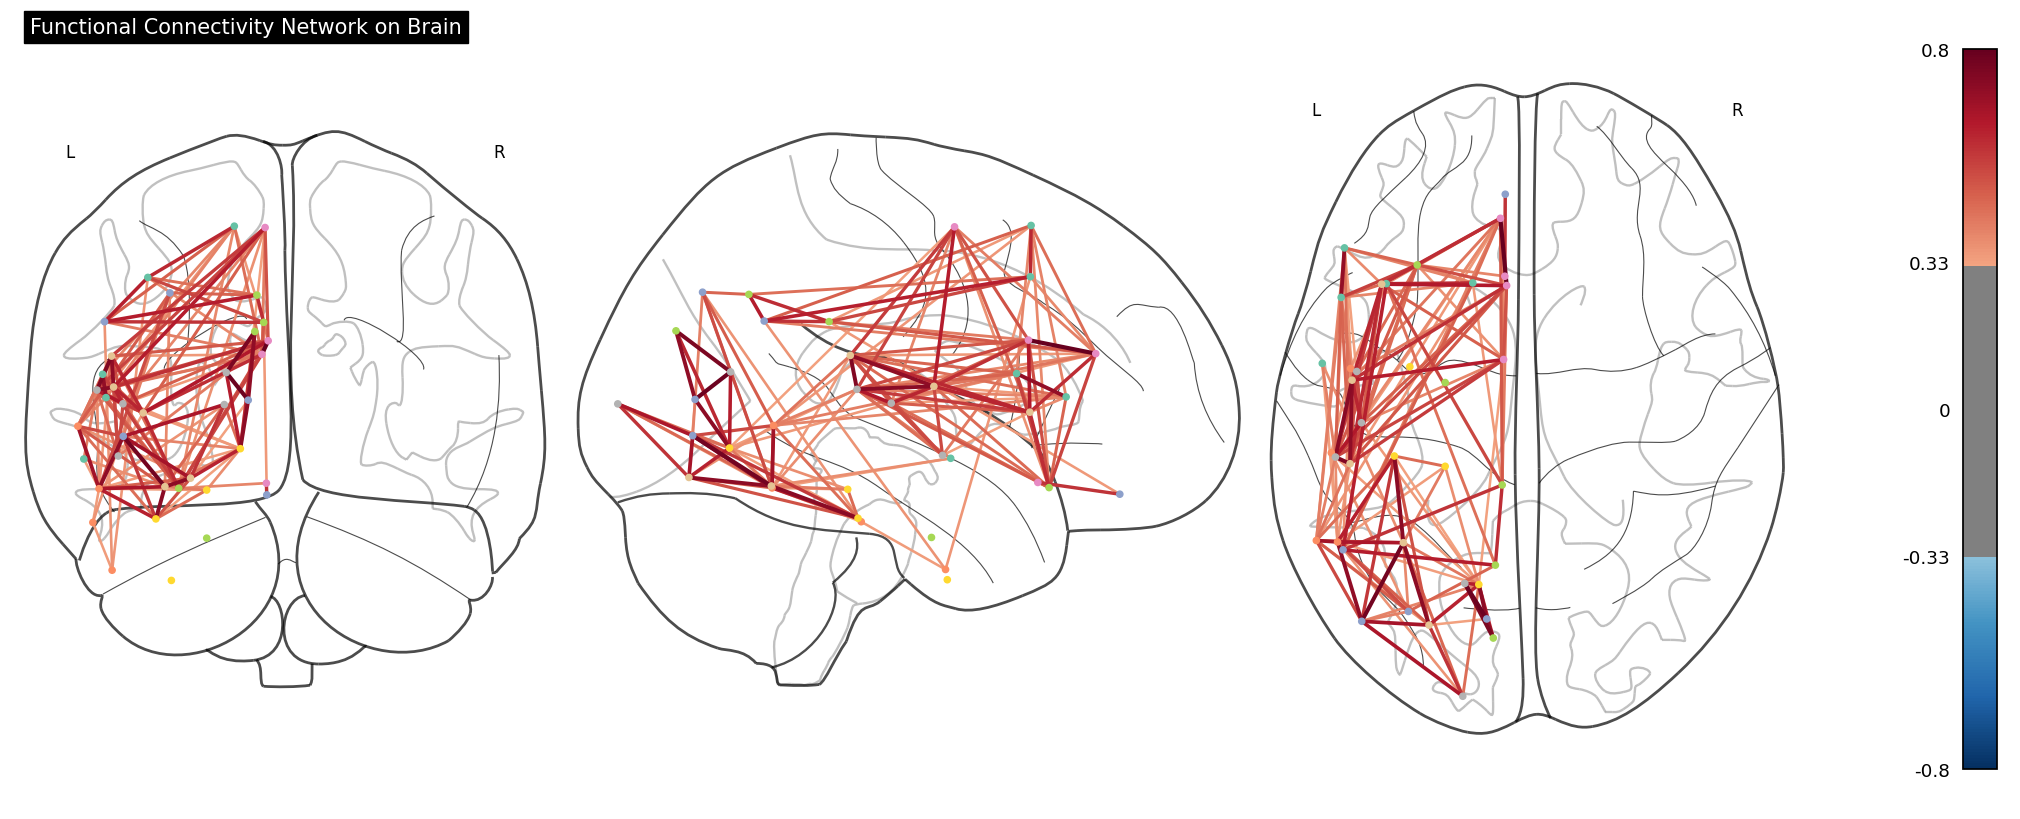

In [26]:
# Visualize network on brain slices
# Create a thresholded connectivity matrix for visualization
thresholded_matrix = correlation_matrix.copy()
thresholded_matrix[np.abs(thresholded_matrix) < threshold] = 0

# Plot connectivity matrix on brain
fig = plt.figure(figsize=(20, 8))

# Use Nilearn's plotting to show network
plotting.plot_connectome(
    thresholded_matrix,
    selected_coords,
    edge_threshold=threshold,
    node_size=20,
    colorbar=True,
    title='Functional Connectivity Network on Brain',
    figure=fig
)

plt.show()

## 8. Advanced Analysis

### 8.1. Weighted Network Analysis

Instead of binary networks, we can analyze weighted networks using the correlation values directly.

In [27]:
# Create weighted graph (using absolute correlation as weights)
weighted_matrix = np.abs(correlation_matrix)
np.fill_diagonal(weighted_matrix, 0)  # No self-connections

# Create weighted NetworkX graph
G_weighted = nx.from_numpy_array(weighted_matrix)

# Compute weighted network metrics
weighted_degree = {i: np.sum(weighted_matrix[i, :]) for i in range(len(selected_labels))}
weighted_clustering = nx.clustering(G_weighted, weight='weight')

# Compare binary vs weighted metrics
comparison_df = pd.DataFrame({
    'ROI': [label[:25] for label in selected_labels],
    'Binary Degree': [degree[i] for i in range(len(selected_labels))],
    'Weighted Degree': [weighted_degree[i] for i in range(len(selected_labels))],
    'Binary Clustering': [clustering[i] for i in range(len(selected_labels))],
    'Weighted Clustering': [weighted_clustering[i] for i in range(len(selected_labels))]
})

comparison_df = comparison_df.sort_values('Weighted Degree', ascending=False)

print("Top 10 Regions by Weighted Degree:")
print(comparison_df.head(10).to_string(index=False))

# Correlation between binary and weighted metrics
corr_degree = np.corrcoef(comparison_df['Binary Degree'], 
                          comparison_df['Weighted Degree'])[0, 1]
corr_clustering = np.corrcoef(comparison_df['Binary Clustering'], 
                              comparison_df['Weighted Clustering'])[0, 1]

print(f"\nCorrelation between binary and weighted metrics:")
print(f"  Degree: {corr_degree:.3f}")
print(f"  Clustering: {corr_clustering:.3f}")

Top 10 Regions by Weighted Degree:
                      ROI  Binary Degree  Weighted Degree  Binary Clustering  Weighted Clustering
Heschl's Gyrus (includes              15        10.618221           0.495238             0.262045
 Central Opercular Cortex             13         9.881582           0.615385             0.241793
            Cuneal Cortex             12         9.754823           0.636364             0.253230
Parahippocampal Gyrus, po             13         9.579566           0.320513             0.243136
 Frontal Opercular Cortex             11         9.575871           0.781818             0.234965
      Paracingulate Gyrus             10         9.076333           0.733333             0.229644
Middle Temporal Gyrus, po             11         8.809240           0.418182             0.233211
Temporal Occipital Fusifo              8         8.698378           0.678571             0.224154
    Frontal Medial Cortex              9         8.598520           0.833333       

### 8.2. Network Hubs

Identify hub regions that are highly connected and central to network function.

In [28]:
# Identify hubs using multiple criteria
# Hub = high degree AND high betweenness centrality

degree_values = np.array(list(degree.values()))
betweenness_values = np.array(list(betweenness.values()))

# Normalize metrics to [0, 1] for comparison
degree_norm = (degree_values - degree_values.min()) / (degree_values.max() - degree_values.min() + 1e-10)
betweenness_norm = (betweenness_values - betweenness_values.min()) / (betweenness_values.max() - betweenness_values.min() + 1e-10)

# Hub score = average of normalized metrics
hub_scores = (degree_norm + betweenness_norm) / 2

# Identify hubs (top 25% of hub scores)
hub_threshold = np.percentile(hub_scores, 75)
hub_indices = np.where(hub_scores >= hub_threshold)[0]

print(f"Hub Regions (Top 25%, Hub Score ≥ {hub_threshold:.3f}):")
print("=" * 70)
hub_data = []
for idx in sorted(hub_indices, key=lambda x: hub_scores[x], reverse=True):
    hub_data.append({
        'ROI': selected_labels[idx],
        'Hub Score': hub_scores[idx],
        'Degree': degree[idx],
        'Betweenness': betweenness[idx]
    })
    print(f"  {selected_labels[idx]:40s}: Hub={hub_scores[idx]:.3f}, "
          f"Degree={degree[idx]:.0f}, Betweenness={betweenness[idx]:.3f}")

hub_df = pd.DataFrame(hub_data)
print(f"\nTotal hubs identified: {len(hub_indices)}")

Hub Regions (Top 25%, Hub Score ≥ 0.407):
  Parahippocampal Gyrus, posterior division: Hub=0.933, Degree=13, Betweenness=0.191
  Heschl's Gyrus (includes H1 and H2)     : Hub=0.822, Degree=15, Betweenness=0.123
  Inferior Temporal Gyrus, posterior division: Hub=0.752, Degree=13, Betweenness=0.122
  Middle Temporal Gyrus, posterior division: Hub=0.631, Degree=11, Betweenness=0.101
  Subcallosal Cortex                      : Hub=0.625, Degree=12, Betweenness=0.086
  Central Opercular Cortex                : Hub=0.560, Degree=13, Betweenness=0.048
  Cuneal Cortex                           : Hub=0.558, Degree=12, Betweenness=0.060
  Planum Polare                           : Hub=0.529, Degree=12, Betweenness=0.049
  Insular Cortex                          : Hub=0.417, Degree=8, Betweenness=0.058
  Paracingulate Gyrus                     : Hub=0.407, Degree=10, Betweenness=0.028

Total hubs identified: 10


## Summary and Key Takeaways

### What We Learned

1. **fMRI Connectivity Fundamentals:**
   - **Functional connectivity**: Temporal correlations in BOLD signals
   - **Resting-state networks**: Spontaneously co-activating brain regions
   - **Correlation matrices**: Primary measure of fMRI connectivity
   - **ROI-based analysis**: Extract time courses from brain regions

2. **Network Construction:**
   - **Correlation matrix**: Pairwise connectivity between all ROI pairs
   - **Thresholding**: Convert to binary network by keeping strongest connections
   - **Weighted networks**: Preserve connection strength information
   - **Community detection**: Identify functionally related regions

3. **Graph Theory Metrics:**
   - **Local metrics**: Degree, clustering, betweenness (node-level)
   - **Global metrics**: Density, efficiency, path length (network-level)
   - **Small-world properties**: Balance between local clustering and global efficiency
   - **Hub regions**: Highly connected, central nodes

4. **Resting-State Networks:**
   - **Default Mode Network**: Self-referential thought
   - **Executive Control Network**: Cognitive control
   - **Salience Network**: Detecting relevant stimuli
   - **Sensorimotor Network**: Motor planning
   - **Visual/Auditory Networks**: Sensory processing

5. **Network Analysis:**
   - **Within-network connectivity**: Stronger than between-network
   - **Modular structure**: Brain organized into functional modules
   - **Hub architecture**: Few highly connected nodes
   - **Small-world topology**: Efficient information transfer

### Best Practices

**Data Preprocessing:**
- Motion correction and denoising are critical
- Confound regression (motion, white matter, CSF)
- Temporal filtering (typically 0.01-0.1 Hz for resting-state)
- Standardization (z-scoring) of time courses

**Network Construction:**
- Choose appropriate parcellation (atlas)
- Consider ROI size and number
- Threshold selection affects network properties
- Compare multiple thresholds or use weighted networks

**Statistical Considerations:**
- Multiple comparisons correction
- Permutation testing for network metrics
- Cross-validation for group comparisons
- Control for motion and other confounds

**Interpretation:**
- Connectivity ≠ direct anatomical connection
- Correlation does not imply causation
- Network metrics depend on threshold choice
- Consider both binary and weighted networks

### Common Pitfalls

1. **Motion Artifacts**: Not correcting → spurious connectivity
2. **Threshold Selection**: Arbitrary thresholds → unreproducible results
3. **ROI Selection**: Too few/many ROIs → biased network properties
4. **Multiple Comparisons**: Not correcting → false positives
5. **Interpretation**: Overinterpreting correlation as causation